# Credit Card Fraud Detection

The goal of this project is to build a machine learning model to detect fraudulent financial transactions.

Challenges:
- Highly imbalanced dataset
- Fraud cases are rare but critical

Objective:
- Maximize recall (catch fraud)
- Maintain reasonable precision

#### 1. Import Libraries

In [380]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPRegressor

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve

from imblearn.over_sampling import SMOTE

#### 2. Load the data

In [381]:
df = pd.read_csv('../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Initial Observations:
- PCA-transformed features
- Already anonymized (for privacy)

#### 3. EDA
##### 3.1 Basic understanding 

In [382]:
df.shape

(284807, 31)

There are 284807 rows and 31 columns

In [383]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

There is no missing value

##### 3.2 Class Imbalance

In [384]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

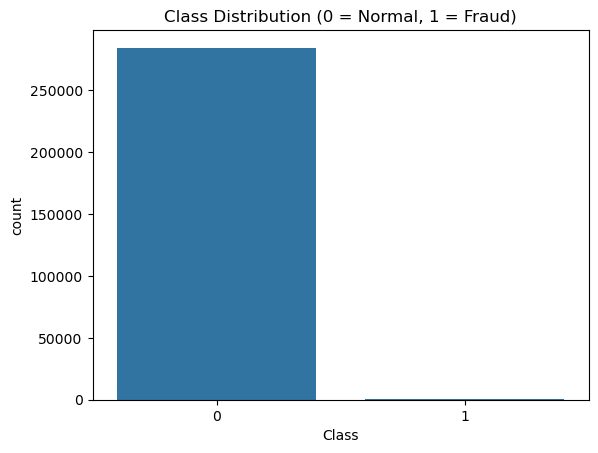

In [385]:
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

Observation:
- Fraud cases are extremely rare
- Dataset is highly imbalanced → special handling required

##### 3.3 Amount vs Fraud

In [386]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


Insights:

1. Fraud is often small-value transactions

- Fraud median (9.25) < Normal median (22)

- Meaning: Fraudsters often test with small transactions. Lower risk of being noticed by users or banks

2. Fraud still includes some large transactions

- Max fraud = 2,125

- Meaning: Not all fraud is small. Some are high-value attacks

3. Normal transactions have much wider range

- Max normal = 25,691

- Meaning: Legitimate users perform: small daily payments and large purchases

4. Fraud distribution is more “concentrated”

- Fraud IQR: 1 → 105

- Normal IQR: 5.65 → 77

- Meaning: Fraud has less variability. Patterns are more consistent, which is easier for ML to learn

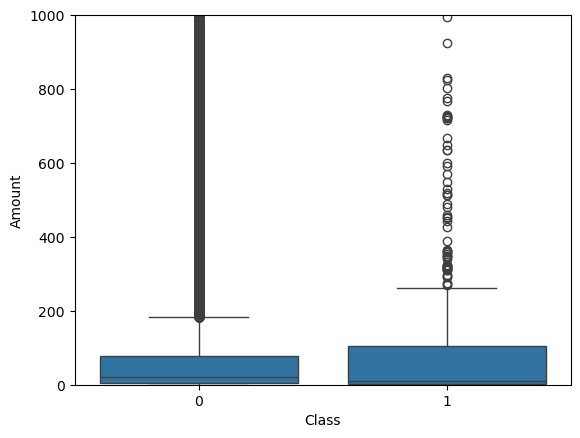

In [387]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.ylim(0, 1000)
plt.show()

Key observations:

1. Fraud has many outliers (wide spread)

- Many dots going up to high values (300–1000+)
- Business meaning: Fraud is not only small transactions. There are high-value fraud attempts. These are high-risk events

3. Normal transactions are more "stable"

- Most normal transactions are within a tighter range
- Fewer extreme outliers (compared visually)
- Business meaning: Legitimate users behave more predictably. Fraud behavior is more irregular / extreme

4. Overlap between fraud and normal

- Both classes overlap a lot
- Critical insight: We cannot detect fraud using amount alone

##### 3.4 Correlation

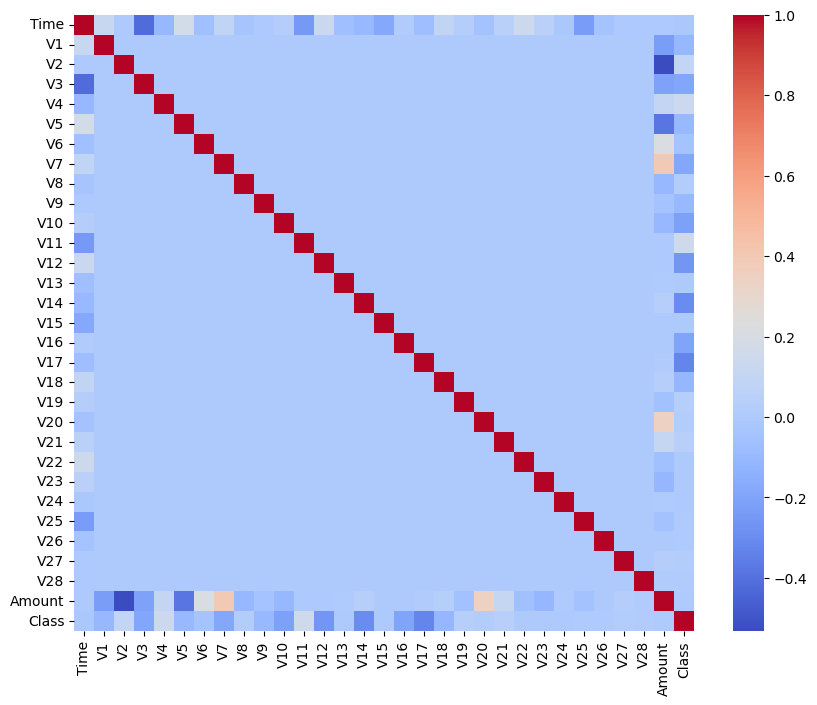

In [388]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

Observations:
- Most features (V1–V28) show low correlation with each other, which is expected because they are generated using PCA transformation.

##### 3.5 Time-based Analysis

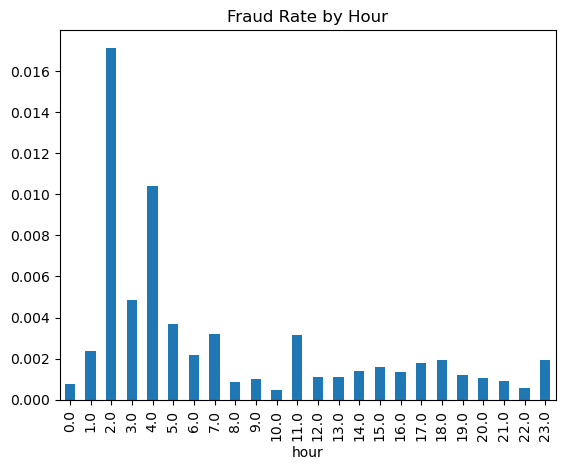

In [389]:
df['hour'] = (df['Time'] // 3600) % 24

fraud_rate = df.groupby('hour')['Class'].mean()

fraud_rate.plot(kind='bar')
plt.title("Fraud Rate by Hour")
plt.show()

- Fraud rates appear higher during early hours (around 2–4 AM), suggesting that fraudulent activities may be more frequent during periods of low user activity.

- Fraud rates are generally lower and more stable during daytime hours, indicating more typical transaction behavior.

- However, the observed pattern is relatively noisy and should be interpreted with caution, as the dataset only contains elapsed time rather than actual timestamps.

- Therefore, time-based features may provide limited but potentially useful signals when combined with other features.

#### 4. Preprocessing

- Drop unused columns:

In [390]:
df = df.drop(['hour'], axis=1)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#### 5. Split Data

In [391]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### 6. Handle Imbalance (SMOTE)

In [392]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [393]:
y_train.value_counts()
y_train_res.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

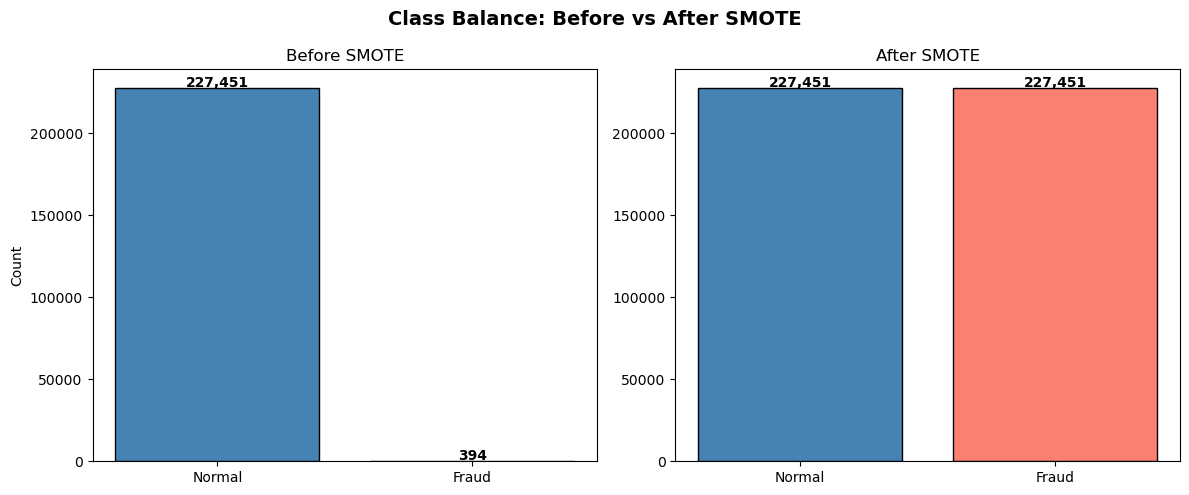

In [394]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
before = y_train.value_counts()
axes[0].bar(['Normal', 'Fraud'], before.values,
            color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title("Before SMOTE")
axes[0].set_ylabel("Count")
for i, v in enumerate(before.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# After SMOTE
after = y_train_res.value_counts()
axes[1].bar(['Normal', 'Fraud'], after.values,
            color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title("After SMOTE")
for i, v in enumerate(after.values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle("Class Balance: Before vs After SMOTE",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

SMOTE balances the dataset by generating synthetic fraud samples.

#### 7. Machine Learning Models
##### 7.1 Logistic Regression 

- Apply scale features on both testing and training sets
- Use the SMOTE resample

In [395]:
# Scale data
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Train model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res_scaled, y_train_res)

# Predict
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Recall: 0.8979591836734694
F1 Score: 0.23342175066312998


- Find the best threshold

In [396]:
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

thresholds = np.linspace(0.01, 0.99, 100)

best_t = 0
best_f1 = 0

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.99
Best F1: 0.7345132743362832


- Check the model performance with the optimal threshold

In [397]:
y_prob = lr.predict_proba(X_test_scaled)[:, 1]
y_pred_opt = (y_prob >= 0.99).astype(int)

print(confusion_matrix(y_test, y_pred_opt))

[[56819    45]
 [   15    83]]


Results meaning:
- 56819 (TN): Normal transactions correctly classified
- 83 (TP): Fraud correctly detected
- 45 (FP): Normal transactions wrongly flagged as fraud
- 15 (FN): Fraud cases missed



##### 7.2 Random Forest 

- Use MOTE resample data
- No need scaling

In [398]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

print("F1 Score:", f1_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

F1 Score: 0.826530612244898
Recall: 0.826530612244898
[[56847    17]
 [   17    81]]


Results meaning:
- 56847 (TN): Normal transactions correctly classified
- 81 (TP): Fraud correctly detected
- 17 (FP): Normal transactions wrongly flagged as fraud
- 17 (FN): Fraud cases missed


##### 7.3 XGBoost

- No need scaling and SMOTE

In [399]:
# 1. Train model
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.01,
    random_state=42
)

xgb.fit(X_train, y_train)

# 2. Get probabilities
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# 3. Find best threshold based on RECALL
best_threshold = 0
best_recall = 0

for t in np.arange(0.01, 1.0, 0.01):
    y_pred = (y_prob_xgb >= t).astype(int)
    recall = recall_score(y_test, y_pred)

    if recall > best_recall:
        best_recall = recall
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best Recall:", best_recall)

# 4. Final predictions using best threshold
y_pred_xgb = (y_prob_xgb >= best_threshold).astype(int)

# 5. Final F1 Score (after threshold tuning)
print("Final F1 Score:", f1_score(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

Best threshold: 0.01
Best Recall: 0.8979591836734694
Final F1 Score: 0.504297994269341
[[56701   163]
 [   10    88]]


Results meaning:
- 56701 (TN): Normal transactions correctly classified
- 88 (TP): Fraud correctly detected
- 163 (FP): Normal transactions wrongly flagged as fraud
- 10 (FN): Fraud cases missed


##### 7.4 LightGBM

In [400]:
# 1. Train model (NO need SMOTE here if using class_weight)
lgb = LGBMClassifier(
    n_estimators=900,
    learning_rate=0.02,
    class_weight='balanced',
    random_state=42
)

lgb.fit(X_train, y_train)

# 2. Get probabilities (IMPORTANT)
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

# 3. Find best threshold (Recall-focused for fraud)
best_threshold = 0
best_recall = 0

for t in np.arange(0.01, 1.0, 0.01):
    y_pred = (y_prob_lgb >= t).astype(int)
    recall = recall_score(y_test, y_pred)

    if recall > best_recall:
        best_recall = recall
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best Recall:", best_recall)

# 4. Final prediction using best threshold
y_pred_lgb = (y_prob_lgb >= best_threshold).astype(int)

# 5. Final F1 score
print("Final F1 Score:", f1_score(y_test, y_pred_lgb))
print(confusion_matrix(y_test, y_pred_lgb))

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001996 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Best threshold: 0.01
Best Recall: 0.8979591836734694
Final F1 Score: 0.7426160337552743
[[56813    51]
 [   10    88]]


Results meaning:
- 56813 (TN): Normal transactions correctly classified
- 88 (TP): Fraud correctly detected
- 51 (FP): Normal transactions wrongly flagged as fraud
- 10 (FN): Fraud cases missed


##### 7.5 Autoencoder with threshold

- Train ONLY on normal data
- No SMOTE
- Need scaling

In [401]:
# Scale (TRAIN only)
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train ONLY on normal data
X_train_normal = X_train_scaled[y_train == 0]

autoencoder = MLPRegressor(
    hidden_layer_sizes=(16, 8, 4, 8, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,   
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

autoencoder.fit(X_train_normal, X_train_normal)

# Reconstruction error
recon = autoencoder.predict(X_test_scaled)
mse = np.mean((X_test_scaled - recon) ** 2, axis=1)

# Threshold search (balanced score)

best_threshold = 0
best_score = 0

thresholds = np.percentile(mse, np.linspace(70, 99.5, 500))

for t in thresholds:
    y_pred = (mse > t).astype(int)

    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    # balanced score (you can adjust weight)
    score = (0.8 * recall) + (0.2 * precision)

    if score > best_score:
        best_score = score
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best score:", best_score)

# Final prediction
y_pred_ae = (mse > best_threshold).astype(int)

print(confusion_matrix(y_test, y_pred_ae))
print("Recall:", recall_score(y_test, y_pred_ae))
print("Precision:", precision_score(y_test, y_pred_ae))

Best threshold: 0.7081939625067353
Best score: 0.7608449810792486
[[45761 11103]
 [    5    93]]
Recall: 0.9489795918367347
Precision: 0.008306538049303322


Results meaning:
- 45761 (TN): Normal transactions correctly classified
- 93 (TP): Fraud correctly detected
- 11103 (FP): Normal transactions wrongly flagged as fraud
- 5 (FN): Fraud cases missed


- Visualize error

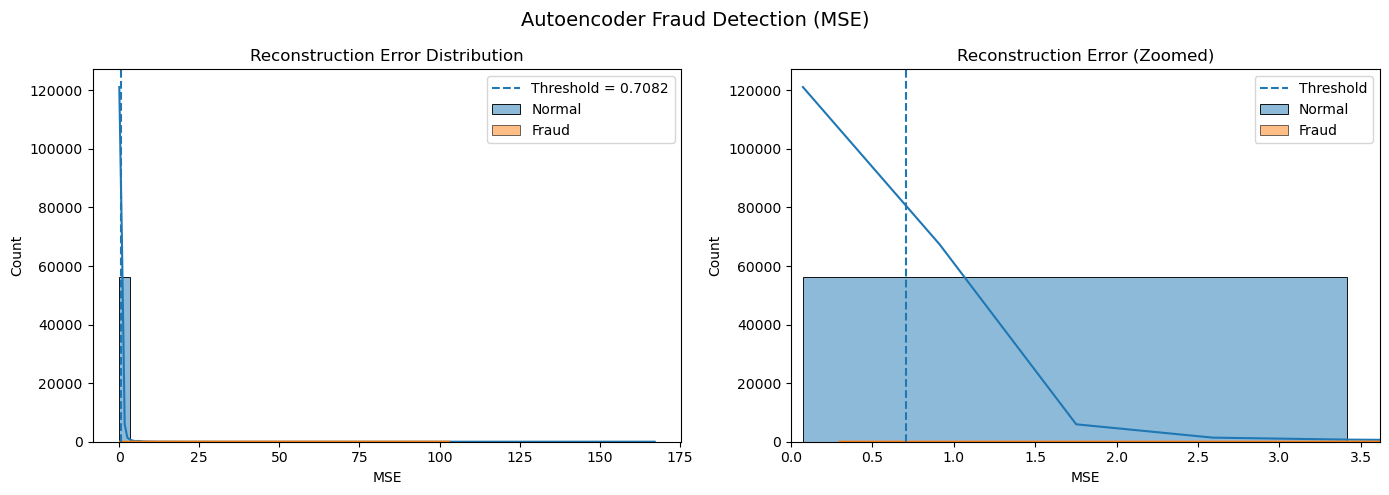

In [402]:
# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Full distribution
sns.histplot(mse[y_test == 0],
             bins=50,
             label='Normal',
             alpha=0.5,
             kde=True,
             ax=axes[0])

sns.histplot(mse[y_test == 1],
             bins=50,
             label='Fraud',
             alpha=0.5,
             kde=True,
             ax=axes[0])

axes[0].axvline(best_threshold,
                linestyle='--',
                label=f'Threshold = {best_threshold:.4f}')

axes[0].set_title("Reconstruction Error Distribution")
axes[0].set_xlabel("MSE")
axes[0].legend()

# 2. Zoomed view 
sns.histplot(mse[y_test == 0],
             bins=50,
             label='Normal',
             alpha=0.5,
             kde=True,
             ax=axes[1])

sns.histplot(mse[y_test == 1],
             bins=50,
             label='Fraud',
             alpha=0.5,
             kde=True,
             ax=axes[1])

axes[1].axvline(best_threshold,
                linestyle='--',
                label='Threshold')

axes[1].set_xlim(0, np.percentile(mse, 99))  # zoom
axes[1].set_title("Reconstruction Error (Zoomed)")
axes[1].set_xlabel("MSE")
axes[1].legend()

plt.suptitle("Autoencoder Fraud Detection (MSE)", fontsize=14)
plt.tight_layout()
plt.show()

Observations:
- The reconstruction error distributions of normal and fraudulent transactions significantly overlap, indicating that fraud patterns are not sufficiently distinct in feature space. As a result, threshold-based anomaly detection leads to high recall but extremely low precision due to a large number of false positives

#### 8. Evaluate Models

##### 8.1 Metrics

In [403]:
results = []

def add_result(name, y_pred, y_prob=None):
    row = {
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
    }
    if y_prob is not None:
        row["ROC-AUC"] = roc_auc_score(y_test, y_prob)
    else:
        row["ROC-AUC"] = None
    results.append(row)

# Logistic Regression (use optimized threshold prediction + ORIGINAL probability)
add_result("Logistic Regression", y_pred_opt, y_prob_lr)

# Random Forest
y_prob_rf = rf.predict_proba(X_test)[:, 1]
add_result("Random Forest", y_pred_rf, y_prob_rf)

# XGBoost
add_result("XGBoost", y_pred_xgb, y_prob_xgb)

# LightGBM
add_result("LightGBM", y_pred_lgb, y_prob_lgb)

# Autoencoder (no probability)
add_result("Autoencoder", y_pred_ae, None)

# Final table

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Recall", ascending=False)

print(results_df)

                 Model  Precision    Recall  F1-score   ROC-AUC
4          Autoencoder   0.008307  0.948980  0.016469       NaN
2              XGBoost   0.350598  0.897959  0.504298  0.973997
3             LightGBM   0.633094  0.897959  0.742616  0.976273
0  Logistic Regression   0.648438  0.846939  0.734513  0.976482
1        Random Forest   0.826531  0.826531  0.826531  0.964421


Precision: % of predicted fraud that is correct  
Recall: % of actual fraud detected  

In fraud detection:
- Recall is more important → missing fraud is costly

#### 9. Confusion Matrix

In [404]:
cm_lr  = confusion_matrix(y_test, y_pred_opt)
cm_rf  = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
cm_ae  = confusion_matrix(y_test, y_pred_ae)

import pandas as pd

def cm_to_metrics(name, cm):
    TN, FP, FN, TP = cm.ravel()
    return {
        "Model": name,
        "TP (Fraud detected)": TP,
        "FN (Fraud missed)": FN,
        "FP (False alarm)": FP,
        "TN (Correct normal)": TN
    }

cm_results = pd.DataFrame([
    cm_to_metrics("Logistic Regression", cm_lr),
    cm_to_metrics("Random Forest", cm_rf),
    cm_to_metrics("XGBoost", cm_xgb),
    cm_to_metrics("LightGBM", cm_lgb),
    cm_to_metrics("Autoencoder", cm_ae),
])

cm_results

,Model,TP (Fraud detected),FN (Fraud missed),FP (False alarm),TN (Correct normal)
0,Logistic Regression,83,15,45,56819
1,Random Forest,81,17,17,56847
2,XGBoost,88,10,163,56701
3,LightGBM,88,10,51,56813
4,Autoencoder,93,5,11103,45761


#### 10. Feature Importance

##### 10.1 Logistic Regression Coefficients

   feature  coefficient
17     V17   -11.250611
14     V14   -10.382002
12     V12    -7.937263
1       V1     7.106124
10     V10    -6.632616
7       V7    -5.998564
5       V5     4.724562
16     V16    -4.691374
3       V3     3.491928
8       V8    -3.079652


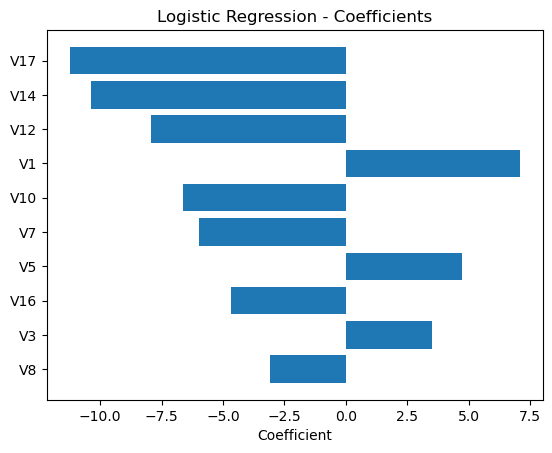

In [405]:
# Logistic Regression coefficients
feat_imp_lr = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_[0]
})

# Sort by absolute importance
feat_imp_lr['abs_coef'] = feat_imp_lr['coefficient'].abs()
feat_imp_lr = feat_imp_lr.sort_values(by='abs_coef', ascending=False)

print(feat_imp_lr[['feature', 'coefficient']].head(10))

# Plot
plt.figure()
plt.barh(feat_imp_lr['feature'][:10][::-1], feat_imp_lr['coefficient'][:10][::-1])
plt.title("Logistic Regression - Coefficients")
plt.xlabel("Coefficient")
plt.show()

- The model shows that features such as V17, V14, and V12 have the strongest negative influence on fraud prediction, indicating that lower values of these features are associated with higher fraud risk.

- Conversely, features like V1, V5, and V3 have positive coefficients, suggesting that higher values increase the likelihood of a transaction being classified as fraudulent.

- Overall, the model relies on a combination of positively and negatively weighted features to distinguish between normal and fraudulent transactions.

##### 10.2 Random Forest Feature Importance

   feature  importance
14     V14    0.217078
10     V10    0.119695
4       V4    0.117379
12     V12    0.107696
17     V17    0.086386
3       V3    0.070782
11     V11    0.049903
16     V16    0.040055
2       V2    0.038862
9       V9    0.028283


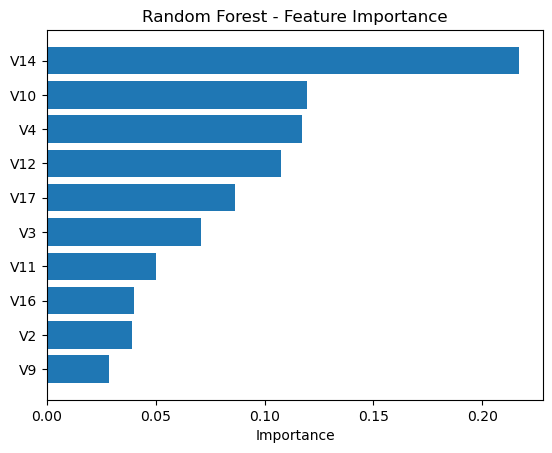

In [406]:
# Random Forest importance
feat_imp_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

# Top 10
print(feat_imp_rf.head(10))

# Plot
plt.figure()
plt.barh(feat_imp_rf['feature'][:10][::-1], feat_imp_rf['importance'][:10][::-1])
plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.show()

- The Random Forest model identifies V14 as the most important feature, followed by V10, V4, and V12, indicating that these variables play a key role in distinguishing fraudulent transactions.

- Several features such as V17, V3, and V11 also contribute meaningfully, suggesting that fraud detection relies on a combination of multiple features rather than a single dominant predictor.

- Overall, the importance is distributed across several variables, highlighting the complexity of fraud patterns and the need for non-linear models to capture these interactions.

##### 10.3 XGBoost Feature Importance

   feature  importance
14     V14    0.331589
10     V10    0.279448
17     V17    0.133995
12     V12    0.048536
4       V4    0.022452
7       V7    0.013654
8       V8    0.010726
11     V11    0.010238
2       V2    0.009726
26     V26    0.009056


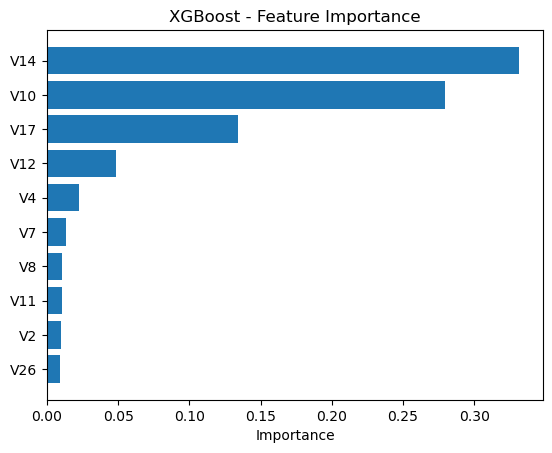

In [407]:
# XGBoost importance
feat_imp_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feat_imp_xgb.head(10))

# Plot
plt.figure()
plt.barh(feat_imp_xgb['feature'][:10][::-1], feat_imp_xgb['importance'][:10][::-1])
plt.title("XGBoost - Feature Importance")
plt.xlabel("Importance")
plt.show()

- The XGBoost model highlights V14 and V10 as the most dominant features, contributing significantly more than others to fraud detection.

- Features such as V17 and V12 also play important roles, while the remaining features have relatively smaller contributions.

- This concentration of importance suggests that XGBoost relies heavily on a few key features to capture strong fraud signals, enabling more precise separation between fraudulent and normal transactions.

##### 10.4 LightGBM Feature Importance

   feature  importance
14     V14        1540
4       V4        1421
26     V26        1365
0     Time        1295
12     V12        1207
10     V10        1080
7       V7        1046
24     V24        1017
13     V13         994
18     V18         965


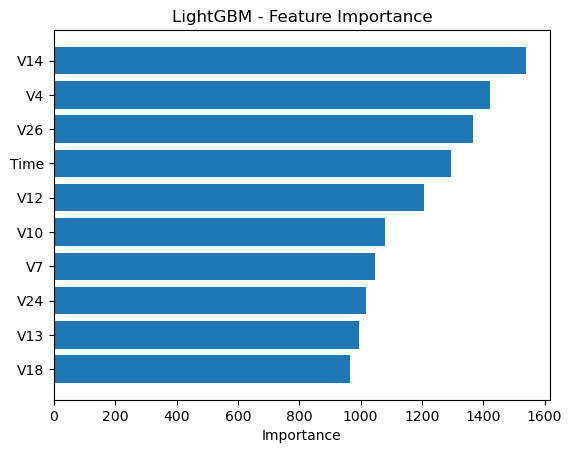

In [408]:
# LightGBM importance
feat_imp_lgb = pd.DataFrame({
    'feature': X.columns,
    'importance': lgb.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feat_imp_lgb.head(10))

# Plot
plt.figure()
plt.barh(feat_imp_lgb['feature'][:10][::-1], feat_imp_lgb['importance'][:10][::-1])
plt.title("LightGBM - Feature Importance")
plt.xlabel("Importance")
plt.show()

- The LightGBM model identifies V14 as the most important feature, consistent with other models, reinforcing its strong predictive power in fraud detection.

- Features such as V4, V26, Time, V12, and V10 also contribute significantly, indicating that LightGBM captures a broader range of signals compared to models like XGBoost.

- Unlike XGBoost, which focuses heavily on a few dominant features, LightGBM distributes importance across more variables, suggesting it leverages a wider set of patterns to detect fraudulent behavior.

##### 10.5 Final Feature Importance Conclusion

- Across all models, V14, V10, V12, and V17 consistently emerge as the most important features for fraud detection. These features appear in top positions in Logistic Regression, Random Forest, XGBoost, and LightGBM, indicating they are strong and reliable predictors of fraudulent behavior.

- Secondary features such as V4, V3, V11, and V16 also contribute meaningfully, though with less consistent impact across models.

- Overall, the results show that fraud detection is driven by a combination of several key features rather than a single variable, highlighting the complexity of fraud patterns.

#### 11. Business Insights

**1. Strong fraud detection capability (high recall)**

* Models like **LightGBM (Recall ≈ 0.90)** and **XGBoost (Recall ≈ 0.90)** successfully capture most fraudulent transactions.
* This is critical in real-world systems where missing fraud (FN) leads directly to financial loss.

**2. Trade-off between fraud detection and customer friction**

* Increasing recall leads to more false positives (FP).

  * Example: XGBoost → high recall but **163 false alarms**
  * Autoencoder → extremely high recall but **11,103 false alarms**
* In practice, too many false alerts can:

  * Interrupt legitimate users
  * Reduce trust in the system
  * Increase operational cost (manual review)

**3. Best practical model choice**

* **LightGBM provides the best balance**:

  * High recall (detects most fraud)
  * Reasonable precision (limits false alarms)
* **Random Forest** is also strong:

  * Lowest FP (only 17)
  * More conservative → misses slightly more fraud

**4. Autoencoder limitation**

* Although recall is very high (~0.95), precision is extremely low (~0.008)
* This means:

  * Model flags *too many normal transactions as fraud*
  * Not usable alone in production
* Root cause:

  * Fraud and normal behavior overlap heavily → poor separation in reconstruction error

**5. Key fraud indicators**

* Features **V14, V10, V12, V17** consistently appear across all models
* These are the most informative signals for detecting fraud patterns

**6. Operational deployment strategy**

Instead of using one model alone:

* Use **LightGBM as primary model**
* Set a **moderate threshold** (not max recall)
* Pipeline approach:

  * Step 1: Model flags suspicious transactions
  * Step 2: High-risk → block or verify (OTP)
  * Step 3: Medium-risk → send to manual review


#### 12. Final Conclusion

This project demonstrates that machine learning models can effectively detect fraudulent credit card transactions despite extreme class imbalance.

Key conclusions:

* **Tree-based models (LightGBM, XGBoost)** outperform others due to their ability to capture complex, non-linear fraud patterns.
* **LightGBM is the best overall model**, achieving:

  * High fraud detection rate (recall)
  * Acceptable false positive rate
  * Strong overall balance (F1-score)
* **Autoencoder is not suitable as a standalone solution** due to poor precision, but may be useful as a supporting anomaly signal.

From a business perspective:

* The system can significantly **reduce fraud losses** by catching most fraudulent transactions early.
* However, **threshold tuning is critical** to balance:

  * Fraud detection (recall)
  * Customer experience (precision)

Final takeaway:

- The optimal fraud detection system is not the one with the highest recall, but the one that **balances fraud prevention and operational cost**, with **LightGBM emerging as the most practical solution** in this case.

